In [1]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device()#drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:3', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 78102)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 74623)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 69895)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 69149)
('cuda:4', 'NVIDIA A100-SXM4-80GB', 58181)
('cuda:1', 'NVIDIA A100-SXM4-80GB', 51601)

# #### Device() ####
# device = cuda:3

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:3)
# edge_attr                (32464, 16)              Tensor (cuda:3)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:3)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

---

In [2]:
from modules.math import library_size, libnorm_transform, z_transform
import seaborn as sns
import torch

In [3]:
def hist_kde(x:torch.Tensor, view=-1):
    x = x.view(view).cpu()
    sns.displot(x, kde=True)

In [4]:
b = _batch.x.reshape(-1, dataset[0].num_nodes, dataset[0].num_node_features)

# library norm
libsize = library_size(b)
libscale = libsize.median()
b_lib = libnorm_transform(b, libsize, libscale)

mu_lib = b_lib.mean(dim=0).view(1,dataset[0].num_nodes, dataset[0].num_node_features)
fc_lib = (b_lib + 1) / (mu_lib + 1)

# log transform
b_log = b_lib.log1p()
fc_log = fc_lib.log()

# z-transform
b_mean = b_log.mean(dim=0, keepdim=True)
b_std = b_log.std(dim=0, keepdim=True)
b_z = z_transform(b_log, b_mean, b_std)

fc_mean = fc_log.mean(dim=0, keepdim=True)
fc_std = fc_log.std(dim=0, keepdim=True)
fc_z = z_transform(fc_log, fc_mean, fc_std)

In [5]:
b_lib[:,:,:].shape

torch.Size([64, 4373, 1])

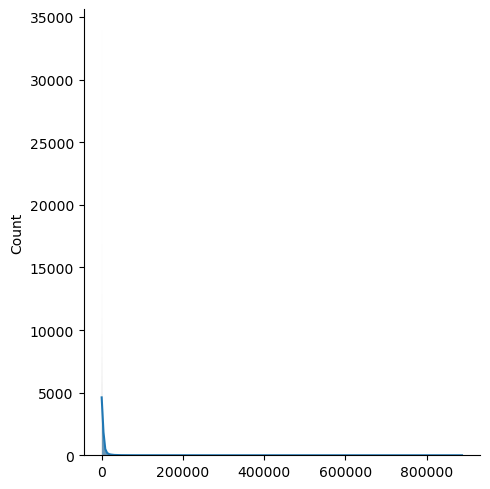

In [6]:
hist_kde(b_lib)

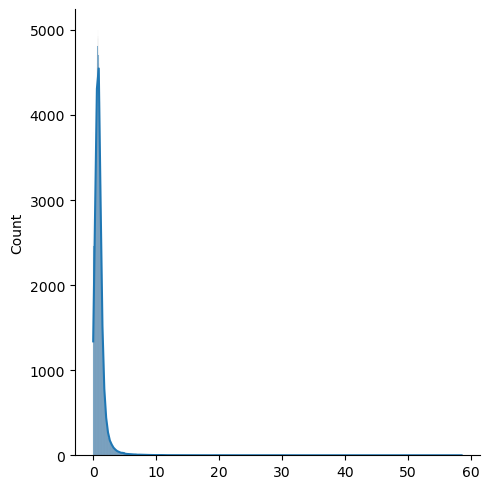

In [7]:
hist_kde(fc_lib)

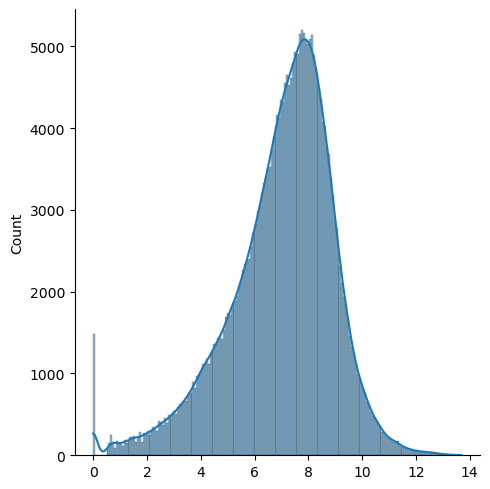

In [8]:
hist_kde(b_log)

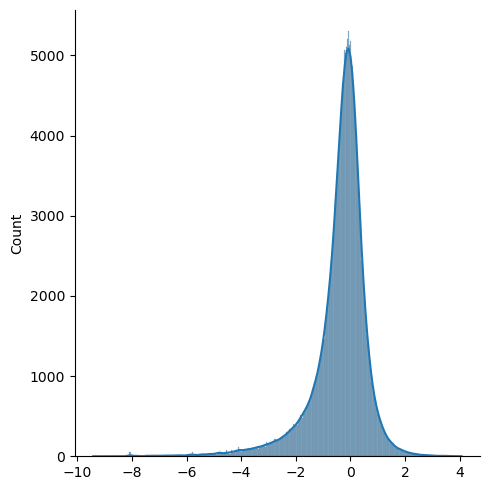

In [9]:
hist_kde(fc_log)

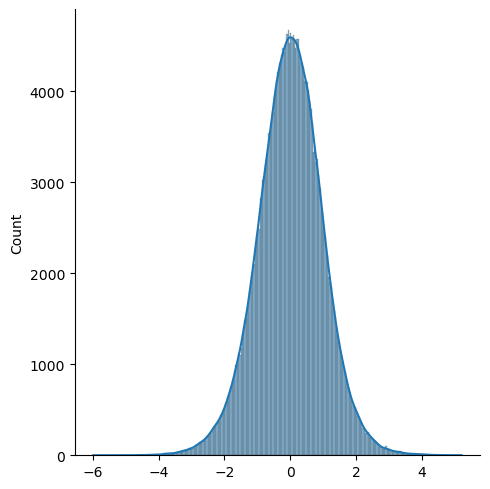

In [10]:
hist_kde(b_z)

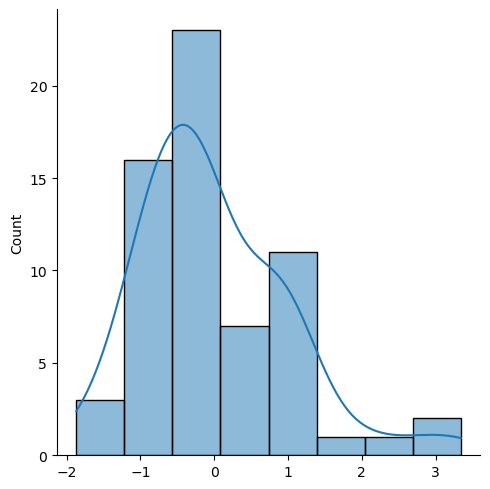

In [18]:
hist_kde(fc_z[:,4])